# 02 EDA desde PostgreSQL

Este notebook consulta las tablas del modelo estrella y genera gráficos para las líneas de análisis del proyecto.

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

usuario = 'postgres'
password = 'Ab123456*'
host = 'localhost'
puerto = '5432'
bd = 'suicidios_colombia'

engine = create_engine(
    f'postgresql+psycopg2://{usuario}:{password}@{host}:{puerto}/{bd}'
)

## Consultas y gráficas

Cada bloque realiza una consulta SQL sobre PostgreSQL y después presenta una gráfica con el resultado.

### 0. Total casos historico

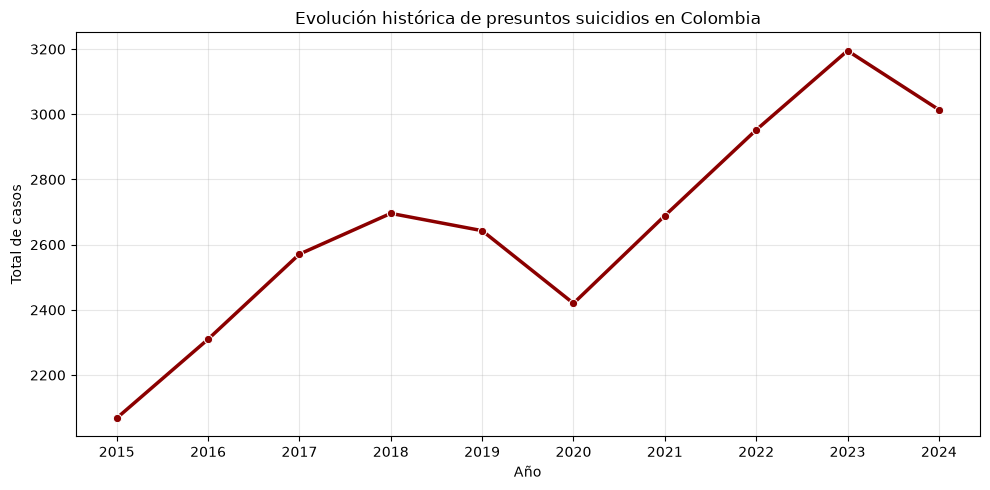

Total histórico de casos registrados: 26.558


In [ ]:
# 0. Evolución histórica de casos en Colombia

query_tendencia = """
SELECT
    dt.anio,
    SUM(f.cantidad) AS total_casos
FROM fact_presuntos_suicidios f
JOIN dim_tiempo dt ON f.id_tiempo = dt.id_tiempo
GROUP BY dt.anio
ORDER BY dt.anio;
"""

df_tendencia = pd.read_sql(query_tendencia, engine)
total_casos = df_tendencia['total_casos'].sum()

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df_tendencia,
    x='anio',
    y='total_casos',
    marker='o',
    linewidth=2.5,
    color='#8B0000'
)

plt.title('Evolución histórica de presuntos suicidios en Colombia')
plt.xlabel('Año')
plt.ylabel('Total de casos')
plt.xticks(df_tendencia['anio'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Total histórico de casos registrados: {total_casos:,}'.replace(',', '.'))

### 1. Diferencias por sexo y causa

En esta gráfica se comparan los casos de suicidio por sexo y mecanismo causal de la lesión fatal. 

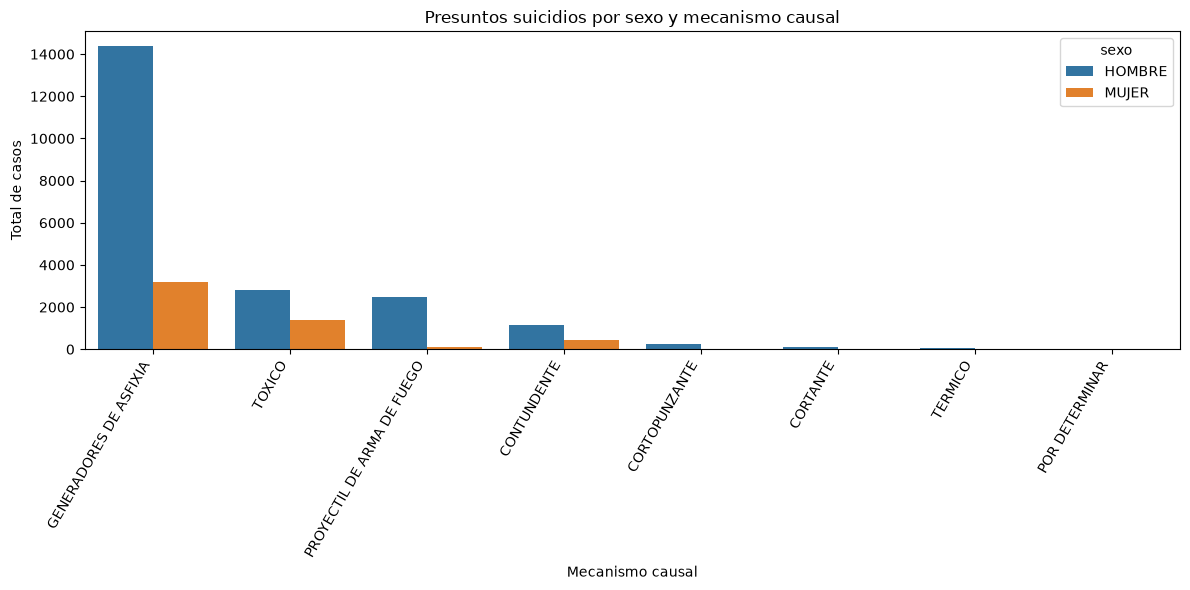

En esta gráfica se comparan los casos de suicidio por sexo y mecanismo causal de la lesión fatal.  
Se observa que, en ambos sexos, los mecanismos más frecuentes son los generadores de asfixia y 
el uso de tóxicos, aunque los hombres concentran una mayor proporción en casi todas las categorías. 
Esta visualización ayuda a identificar patrones diferenciales por sexo y a describir la distribución 
de los mecanismos más usados, pero no permite afirmar causalidad ni comparar tasas ajustadas por población.


In [40]:
# 1. Diferencias por sexo y mecanismo causal
query_sexo_mecanismo = """
SELECT
    dv.sexo,
    dc.mecanismo_causal,
    SUM(f.cantidad) AS total_casos
FROM fact_presuntos_suicidios f
JOIN dim_victima dv ON f.id_victima = dv.id_victima
JOIN dim_circunstancia dc ON f.id_circunstancia = dc.id_circunstancia
GROUP BY dv.sexo, dc.mecanismo_causal
ORDER BY total_casos DESC;
"""

df_sexo_mecanismo = pd.read_sql(query_sexo_mecanismo, engine)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_sexo_mecanismo.head(12),
    x='mecanismo_causal',
    y='total_casos',
    hue='sexo'
)
plt.title('Presuntos suicidios por sexo y mecanismo causal')
plt.xlabel('Mecanismo causal')
plt.ylabel('Total de casos')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

print("En esta gráfica se comparan los casos de suicidio por sexo y mecanismo causal de la lesión fatal.  \n" \
        "Se observa que, en ambos sexos, los mecanismos más frecuentes son los generadores de asfixia y \n" \
        "el uso de tóxicos, aunque los hombres concentran una mayor proporción en casi todas las categorías. \n" \
        "Esta visualización ayuda a identificar patrones diferenciales por sexo y a describir la distribución \n" \
        "de los mecanismos más usados, pero no permite afirmar causalidad ni comparar tasas ajustadas por población.")

### 2. Edad y ciclo vital

En esta consulta agrupamos los registros por ciclo vital, grupo de edad y condición de mayoría de edad. La gráfica permite observar qué etapas concentran más casos. Se comparan cantidades de registros, no tasas por población.

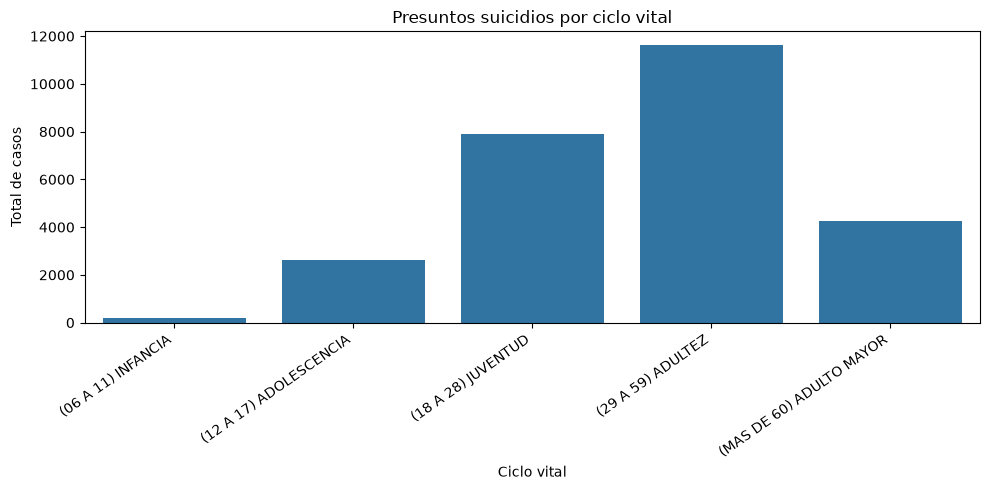

En esta gráfica se agrupan los casos por ciclo vital y se observa que la mayor concentración 
corresponde a la juventud y la adultez, mientras que la adolescencia y la infancia muestran 
frecuencias mucho menores. Esto indica que los registros se concentran principalmente en etapas 
adultas, pero no permite afirmar diferencias de riesgo por población ni establecer causalidad, 
porque la visualización representa cantidades absolutas y no tasas ajustadas por población o 
estructura demográfica. La comparación es descriptiva y ayuda a identificar dónde está más 
concentrada la carga de casos en la muestra.


In [41]:
# 2. Edad y ciclo vital
query_edad = """
SELECT
    dv.ciclo_vital,
    dv.grupo_edad_quinquenal,
    dv.grupo_mayor_menor_edad,
    SUM(f.cantidad) AS total_casos
FROM fact_presuntos_suicidios f
JOIN dim_victima dv ON f.id_victima = dv.id_victima
GROUP BY dv.ciclo_vital, dv.grupo_edad_quinquenal,
         dv.grupo_mayor_menor_edad
ORDER BY total_casos DESC;
"""

df_edad = pd.read_sql(query_edad, engine)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_edad.groupby('ciclo_vital', as_index=False)['total_casos'].sum(),
    x='ciclo_vital',
    y='total_casos'
)
plt.title('Presuntos suicidios por ciclo vital')
plt.xlabel('Ciclo vital')
plt.ylabel('Total de casos')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

print(
    "En esta gráfica se agrupan los casos por ciclo vital y se observa que la mayor concentración \n"
    "corresponde a la juventud y la adultez, mientras que la adolescencia y la infancia muestran \n"
    "frecuencias mucho menores. Esto indica que los registros se concentran principalmente en etapas \n"
    "adultas, pero no permite afirmar diferencias de riesgo por población ni establecer causalidad, \n"
    "porque la visualización representa cantidades absolutas y no tasas ajustadas por población o \n"
    "estructura demográfica. La comparación es descriptiva y ayuda a identificar dónde está más \n"
    "concentrada la carga de casos en la muestra."
)

### 3. Tiempo

Revisamos los días de la semana y los rangos de hora para buscar concentraciones temporales.

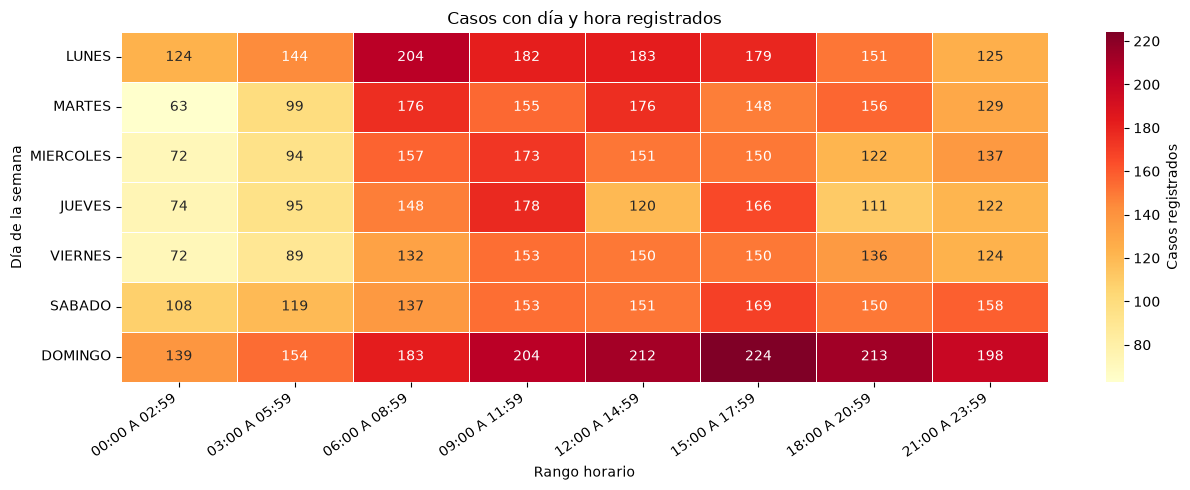

Los casos se concentran principalmente los DOMINGO y en el rango 
09:00 A 11:59. La combinación con mayor frecuencia fue 
DOMINGO entre 15:00 A 17:59. 
La información sin día u hora fue excluida para evitar que domine 
la escala de colores.


In [42]:
# 3. Estacionalidad, dí­a y rango de hora

query_tiempo_reg = """
SELECT
    dt.dia,
    REPLACE(REPLACE(dt.rango_hora_3h, '(', ''), ')', '') AS rango_hora,
    SUM(f.cantidad) AS total_casos
FROM fact_presuntos_suicidios f
JOIN dim_tiempo dt ON f.id_tiempo = dt.id_tiempo
WHERE dt.dia <> 'SIN INFORMACION'
  AND dt.rango_hora_3h <> 'SIN INFORMACION'
GROUP BY dt.dia, dt.rango_hora_3h
ORDER BY total_casos DESC;
"""

df_reg = pd.read_sql(query_tiempo_reg, engine)

tabla = (
    df_reg.assign(
        rango_hora=df_reg['rango_hora']
        .str.replace(r'[()]', '', regex=True)
        .str.strip()
    )
    .groupby(['dia', 'rango_hora'], as_index=False)['total_casos']
    .sum()
    .pivot(index='dia', columns='rango_hora', values='total_casos')
    .fillna(0)
    .reindex(
        index=['LUNES', 'MARTES', 'MIERCOLES', 'JUEVES', 'VIERNES', 'SABADO', 'DOMINGO'],
        columns=[
            '00:00 A 02:59', '03:00 A 05:59', '06:00 A 08:59', '09:00 A 11:59',
            '12:00 A 14:59', '15:00 A 17:59', '18:00 A 20:59', '21:00 A 23:59'
        ],
        fill_value=0
    )
)

plt.figure(figsize=(13, 5))
sns.heatmap(
    tabla,
    cmap='YlOrRd',
    annot=True,
    fmt='.0f',
    linewidths=.5,
    cbar_kws={'label': 'Casos registrados'}
)

plt.title('Casos con día y hora registrados')
plt.xlabel('Rango horario')
plt.ylabel('Día de la semana')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

dia_max = tabla.sum(axis=1).idxmax()
hora_max = tabla.sum(axis=0).idxmax()
celda_max = tabla.stack().idxmax()

print(
    f"Los casos se concentran principalmente los {dia_max} y en el rango \n"
    f"{hora_max}. La combinación con mayor frecuencia fue \n"
    f"{celda_max[0]} entre {celda_max[1]}. \n"
    "La información sin día u hora fue excluida para evitar que domine \n"
    "la escala de colores."
)


### 4. Diferencias territoriales

Comparamos los registros por departamento y zona del hecho. Las ciudades grandes pueden tener más casos por su tamaño poblacional, por eso no se interpretan estos valores como tasas.

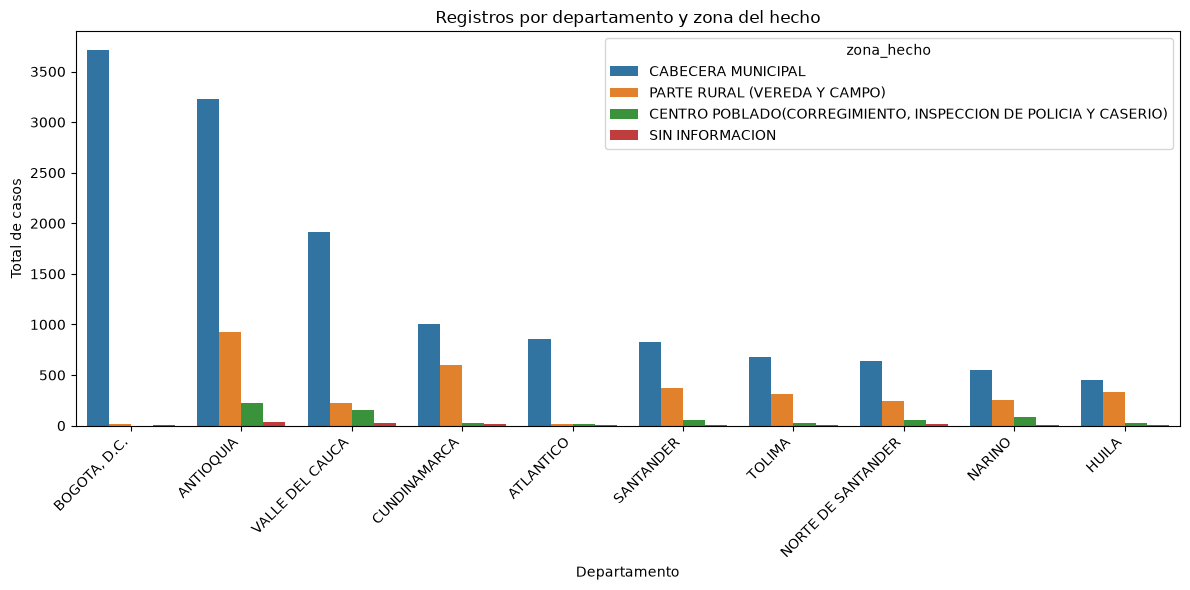

In [43]:
# 4. Diferencias territoriales entre zonas
query_zonas = """
SELECT
    dg.departamento,
    dg.zona_hecho,
    SUM(f.cantidad) AS total_casos
FROM fact_presuntos_suicidios f
JOIN dim_geografia dg ON f.id_geografia = dg.id_geografia
GROUP BY dg.departamento, dg.zona_hecho
ORDER BY total_casos DESC;
"""

df_zonas = pd.read_sql(query_zonas, engine)
top_departamentos = (
    df_zonas.groupby('departamento')['total_casos']
    .sum()
    .nlargest(10)
    .index
)
df_zonas_top = df_zonas[df_zonas['departamento'].isin(top_departamentos)]

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_zonas_top,
    x='departamento',
    y='total_casos',
    hue='zona_hecho'
)
plt.title('Registros por departamento y zona del hecho')
plt.xlabel('Departamento')
plt.ylabel('Total de casos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5. Razón reportada y estado civil

La consulta cruza la razón reportada con el estado civil. La gráfica sirve para describir qué combinaciones aparecen con mayor frecuencia. La razón registrada no se interpreta automáticamente como una causa médica comprobada.

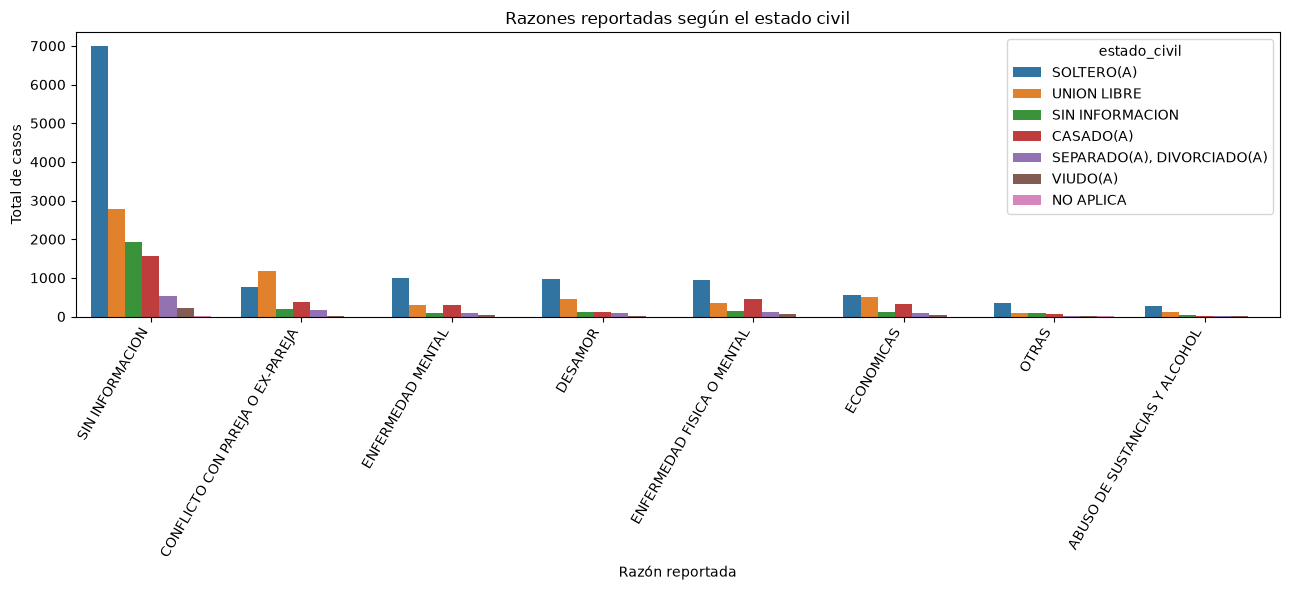

In [44]:
# 5. Razón reportada y estado civil
query_razon = """
SELECT
    dv.estado_civil,
    dc.razon_suicidio,
    SUM(f.cantidad) AS total_casos
FROM fact_presuntos_suicidios f
JOIN dim_victima dv ON f.id_victima = dv.id_victima
JOIN dim_circunstancia dc ON f.id_circunstancia = dc.id_circunstancia
GROUP BY dv.estado_civil, dc.razon_suicidio
ORDER BY total_casos DESC;
"""

df_razon = pd.read_sql(query_razon, engine)
top_razones = (
    df_razon.groupby('razon_suicidio')['total_casos']
    .sum()
    .nlargest(8)
    .index
)
df_razon_top = df_razon[df_razon['razon_suicidio'].isin(top_razones)]

plt.figure(figsize=(13, 6))
sns.barplot(
    data=df_razon_top,
    x='razon_suicidio',
    y='total_casos',
    hue='estado_civil'
)
plt.title('Razones reportadas según el estado civil')
plt.xlabel('Razón reportada')
plt.ylabel('Total de casos')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

### 6. Escolaridad

Aquí agrupamos los registros por nivel educativo. Las categorías fueron homologadas durante el ETL para facilitar la comparación. La gráfica muestra distribución de registros y no permite concluir que la escolaridad sea un factor protector.

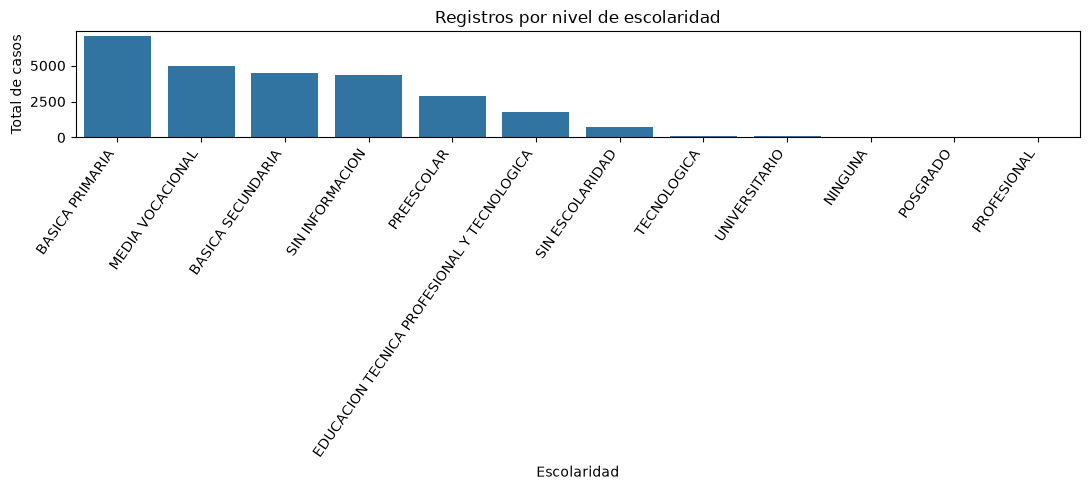

In [45]:
# 6. Escolaridad y razón reportada
query_escolaridad = """
SELECT
    dv.escolaridad,
    dc.razon_suicidio,
    SUM(f.cantidad) AS total_casos
FROM fact_presuntos_suicidios f
JOIN dim_victima dv ON f.id_victima = dv.id_victima
JOIN dim_circunstancia dc ON f.id_circunstancia = dc.id_circunstancia
GROUP BY dv.escolaridad, dc.razon_suicidio
ORDER BY total_casos DESC;
"""

df_escolaridad = pd.read_sql(query_escolaridad, engine)
df_escolaridad_total = (
    df_escolaridad.groupby('escolaridad', as_index=False)['total_casos']
    .sum()
    .sort_values('total_casos', ascending=False)
)

plt.figure(figsize=(11, 5))
sns.barplot(
    data=df_escolaridad_total,
    x='escolaridad',
    y='total_casos'
)
plt.title('Registros por nivel de escolaridad')
plt.xlabel('Escolaridad')
plt.ylabel('Total de casos')
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.show()

### 7. Calidad de las variables sensibles

Finalmente revisamos cuántos registros tienen valores como SIN INFORMACION, NO REGISTRA o NO HABIA SIDO IMPLEMENTADA en variables sensibles. Esto ayuda a conocer las limitaciones del conjunto antes de interpretar los resultados.

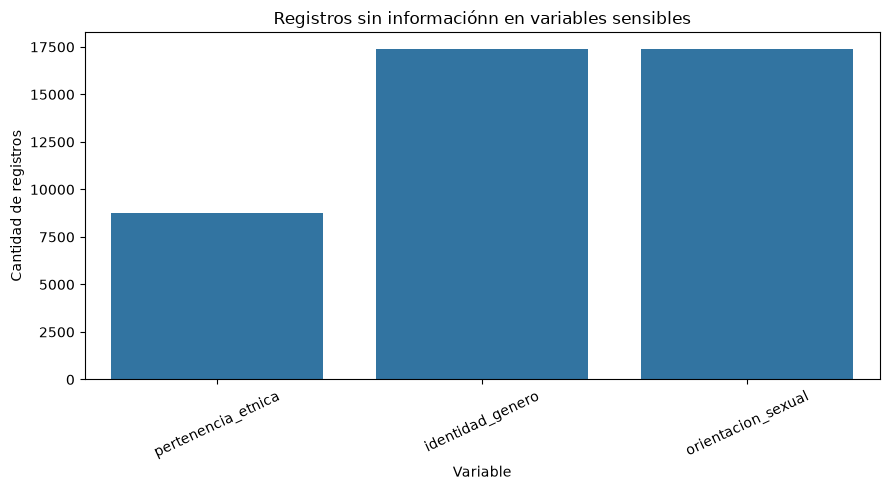

In [ ]:
# 7. Calidad del dato en variables sensibles
query_calidad = """
SELECT 'pertenencia_etnica' AS variable,
       COUNT(*) FILTER (WHERE dv.pertenencia_etnica IN
       ('SIN INFORMACION', 'NO REGISTRA')) AS registros_sin_info
FROM fact_presuntos_suicidios f
JOIN dim_victima dv ON f.id_victima = dv.id_victima
UNION ALL
SELECT 'orientacion_sexual',
       COUNT(*) FILTER (WHERE dv.orientacion_sexual IN
       ('SIN INFORMACION', 'NO REGISTRA', 'NO HABIA SIDO IMPLEMENTADA'))
FROM fact_presuntos_suicidios f
JOIN dim_victima dv ON f.id_victima = dv.id_victima
UNION ALL
SELECT 'identidad_genero',
       COUNT(*) FILTER (WHERE dv.identidad_genero IN
       ('SIN INFORMACION', 'NO REGISTRA', 'NO HABIA SIDO IMPLEMENTADA'))
FROM fact_presuntos_suicidios f
JOIN dim_victima dv ON f.id_victima = dv.id_victima;
"""

df_calidad = pd.read_sql(query_calidad, engine)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_calidad,
    x='variable',
    y='registros_sin_info'
)
plt.title('Registros sin información en variables sensibles')
plt.xlabel('Variable')
plt.ylabel('Cantidad de registros')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()